In [3]:
import pandas as pd

# Utils

In [4]:
genome_sizes = {'mGorGor1': 3545834224,
 'mPanPan1': 3244888708,
 'mPanTro3': 3177739762,
 'mPonAbe1': 3259853530,
 'mPonPyg2': 3220935163,
 'CHM13': 3117275501}

NUMT_counts = {
    "mGorGor1": 701,
    "mPanPan1": 840,
    "mPanTro3": 822,
    "mPonAbe1": 820,
    "mPonPyg2": 808,
    "mSymSyn1": 610,
    "CHM13": 780
}

NUMT_totalbp = {
    "mGorGor1": 579213,
    "mPanPan1": 809537,
    "mPanTro3": 738980,
    "mPonAbe1": 696333,
    "mPonPyg2": 769860,
    "mSymSyn1": 487043,
    "CHM13": 593589
}

# Create a mapping from assembly names to common species names
assembly_to_species = {
    'mPanPan1': 'Bonobo',
    'mPanTro3': 'Chimpanzee',
    'CHM13': 'Human',
    'mGorGor1': 'Gorilla',
    'mPonPyg2': 'B. orangutan',
    'mPonAbe1': 'S. orangutan',
    'mSymSyn1': 'Siamang',
}
# Set species order for the plot
species_order = ['Bonobo', 'Chimpanzee', 'Human', 'Gorilla', 'B. orangutan', 'S. orangutan', 'Siamang']


dict_annot = {'enhancer':'Enhancers', 'exon':'Exons', 'gene_nonprotCode':'NPC Genes', 
                  'gene_protCode':'PC Genes', 'intron':'Introns', 'ngnr':'NFNR', #'Non-functional, \nnon-repetitive regions', 
                  'promoter':'Promoter', 'repeats':'Repeat', 'all NUMT':'all NUMT', 'cds':'CDS','utr5':'UTR5','utr3':'UTR3','te':'TE','simple':'Simple/LCR','satellite':'Satellite','all NUMTs':'all NUMTs', 'nonTE':'non-TE repeats', 'nonTe':'non-TE repeats', 'nf_te':'Non-funct TE'}
# Set annotations order for the plot
subset_annots = [ 'promoter','enhancer','utr5','cds','utr3','intron','gene_nonprotCode','te','nonTe','ngnr' ]


palette7 = ["#005f73", "#0a9396", "#94d2bd", "#e9d8a6", "#ca6702", "#9b2226", "#450000" ]

# Merge bootstrap results

In [5]:
import os

bootstrap_results = []

for file in os.listdir("./backup_boots/"):
    if file.endswith(".simpl_bootstrap_frequencies.txt"):
        assembly = file.split(".")[0]  # Extract assembly & feature
        feature = file.split(".")[1]
        with open(f"./backup_boots/{file}", "r") as f:
            first_line = f.readline().strip()
            if first_line.replace(".", "", 1).isdigit():  # Check if it's a number
                bootstrap_results.append({
                    "Bootstrap_Frequency": float(first_line),
                    "Assembly": assembly,
                    "Feature": feature
                })
            for line in f:
                if line.strip():  # Ignore empty lines
                    try:
                        bootstrap_results.append({
                            "Bootstrap_Frequency": float(line.strip()),
                            "Assembly": assembly,
                            "Feature": feature
                        })
                    except ValueError:
                        print(f"Skipping invalid line in {file}: {line.strip()}")

                        # Export the merged bootstrap_results to a CSV file
                        output_file = os.path.join("./backup_boots/", "merged_bootstrap_results.tsv")
                        bootstrap_results.to_csv(output_file, index=False)

                        print(f"Merged bootstrap results saved to {output_file}")

# Print preview
bootstrap_results = pd.DataFrame(bootstrap_results)

# Map species and annotation names using dict_assembly_species
bootstrap_results["Species"] = bootstrap_results["Assembly"].map(assembly_to_species)
bootstrap_results["Feature_Annotation"] = bootstrap_results["Feature"].map(dict_annot)

bootstrap_results

,Bootstrap_Frequency,Assembly,Feature,Species,Feature_Annotation
0,0.000061,mPonAbe1,nonTe,S. orangutan,non-TE repeats
1,0.000057,mPonAbe1,nonTe,S. orangutan,non-TE repeats
2,0.000098,mPonAbe1,nonTe,S. orangutan,non-TE repeats
3,0.000072,mPonAbe1,nonTe,S. orangutan,non-TE repeats
4,0.000078,mPonAbe1,nonTe,S. orangutan,non-TE repeats
...,...,...,...,...,...
101995,0.000105,mPonAbe1,te,S. orangutan,TE
101996,0.000106,mPonAbe1,te,S. orangutan,TE
101997,0.000104,mPonAbe1,te,S. orangutan,TE
101998,0.000112,mPonAbe1,te,S. orangutan,TE


# Convert bootstrap fractions into number of NUMT overlaps

In [6]:
# Features counts
bootstrap_factors = pd.read_table("counts_all_features.txt", names=['Assembly','Feature','Feature_counts'])
bootstrap_factors

# Define genome sizes
genome_sizes = {'mGorGor1': 3545834224,
 'mPanPan1': 3244888708,
 'mPanTro3': 3177739762,
 'mPonAbe1': 3259853530,
 'mPonPyg2': 3220935163,
 'CHM13': 3117275501}

NUMT_counts = {
    "mGorGor1": 701,
    "mPanPan1": 840,
    "mPanTro3": 822,
    "mPonAbe1": 820,
    "mPonPyg2": 808,
    "mSymSyn1": 610,
    "CHM13": 780
}

NUMT_totalbp = {
    "mGorGor1": 579213,
    "mPanPan1": 809537,
    "mPanTro3": 738980,
    "mPonAbe1": 696333,
    "mPonPyg2": 769860,
    "mSymSyn1": 487043,
    "CHM13": 593589
}

# Merge bootstrap_results with bootstrap_factors on Assembly and Feature
merged_results = pd.merge(
    bootstrap_results,
    bootstrap_factors,
    on=["Assembly", "Feature"],
    how="inner"
)

# Multiply Bootstrap_Frequency by Feature_counts
merged_results["Boot_NUMT_overlaps"] = (
    merged_results["Bootstrap_Frequency"] * merged_results["Feature_counts"]
)

# Export the merged results with Boot_NUMT_overlaps to a CSV file
output_file = os.path.join("./backup_boots/", "bootstrap_numt_overlaps.tsv")
merged_results.to_csv(output_file, sep="\t", index=False)

print(f"Bootstrap NUMT overlaps saved to {output_file}")

# Display the updated DataFrame
merged_results

Bootstrap NUMT overlaps saved to ./backup_boots/bootstrap_numt_overlaps.tsv


,Bootstrap_Frequency,Assembly,Feature,Species,Feature_Annotation,Feature_counts,Boot_NUMT_overlaps
0,0.000061,mPonAbe1,nonTe,S. orangutan,non-TE repeats,847858,52.0
1,0.000057,mPonAbe1,nonTe,S. orangutan,non-TE repeats,847858,48.0
2,0.000098,mPonAbe1,nonTe,S. orangutan,non-TE repeats,847858,83.0
3,0.000072,mPonAbe1,nonTe,S. orangutan,non-TE repeats,847858,61.0
4,0.000078,mPonAbe1,nonTe,S. orangutan,non-TE repeats,847858,66.0
...,...,...,...,...,...,...,...
101995,0.000105,mPonAbe1,te,S. orangutan,TE,4056763,427.0
101996,0.000106,mPonAbe1,te,S. orangutan,TE,4056763,428.0
101997,0.000104,mPonAbe1,te,S. orangutan,TE,4056763,421.0
101998,0.000112,mPonAbe1,te,S. orangutan,TE,4056763,454.0


# Compute bootstrap enrichment 

In [7]:
feature_totalbp_df = pd.read_table('features_totalbp.txt')
feature_totalbp_df

# Map feature totalbp to merged_df
feature_totalbp_dict = feature_totalbp_df.set_index('Assembly').to_dict(orient='index')
merged_results['Feature_TotalBP'] = merged_results.apply(
    lambda row: feature_totalbp_dict.get(row['Assembly'], {}).get(row['Feature'], None), axis=1
)

# Map Genome sizes, NUMT_counts and NUMT_totalbp to the results
merged_results["Genome_Size"] = merged_results["Assembly"].map(genome_sizes)
merged_results["NUMT_Counts"] = merged_results["Assembly"].map(NUMT_counts)
merged_results["NUMT_TotalBP"] = merged_results["Assembly"].map(NUMT_totalbp)

# Compute enrichment
merged_results['Enrichment'] = (
    (merged_results['Boot_NUMT_overlaps'] / merged_results['NUMT_Counts']) /
    (merged_results['Feature_TotalBP'] / merged_results['Genome_Size'])
)

merged_results

,Bootstrap_Frequency,Assembly,Feature,Species,Feature_Annotation,Feature_counts,Boot_NUMT_overlaps,Feature_TotalBP,Genome_Size,NUMT_Counts,NUMT_TotalBP,Enrichment
0,0.000061,mPonAbe1,nonTe,S. orangutan,non-TE repeats,847858,52.0,328843028,3259853530,820,696333,0.628636
1,0.000057,mPonAbe1,nonTe,S. orangutan,non-TE repeats,847858,48.0,328843028,3259853530,820,696333,0.580279
2,0.000098,mPonAbe1,nonTe,S. orangutan,non-TE repeats,847858,83.0,328843028,3259853530,820,696333,1.003399
3,0.000072,mPonAbe1,nonTe,S. orangutan,non-TE repeats,847858,61.0,328843028,3259853530,820,696333,0.737438
4,0.000078,mPonAbe1,nonTe,S. orangutan,non-TE repeats,847858,66.0,328843028,3259853530,820,696333,0.797884
...,...,...,...,...,...,...,...,...,...,...,...,...
101995,0.000105,mPonAbe1,te,S. orangutan,TE,4056763,427.0,1459711035,3259853530,820,696333,1.162908
101996,0.000106,mPonAbe1,te,S. orangutan,TE,4056763,428.0,1459711035,3259853530,820,696333,1.165631
101997,0.000104,mPonAbe1,te,S. orangutan,TE,4056763,421.0,1459711035,3259853530,820,696333,1.146567
101998,0.000112,mPonAbe1,te,S. orangutan,TE,4056763,454.0,1459711035,3259853530,820,696333,1.236440


# Plot enrichment

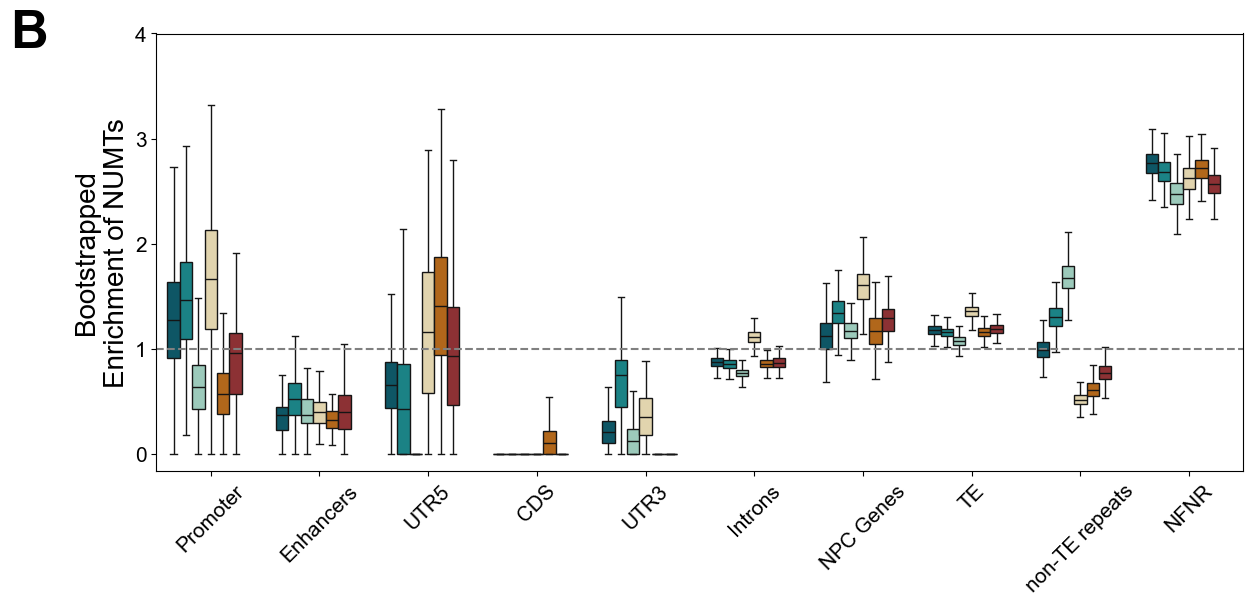

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial'

# Subset and reorder annotations.
merged_results = merged_results[merged_results['Feature'].isin(subset_annots)]
annot_order = [dict_annot[annot] for annot in subset_annots]

# Plot the enrichment values
plt.figure(figsize=(12, 6))

sns.boxplot(
    x='Feature_Annotation', 
    y='Enrichment', 
    hue='Species', 
    order=annot_order, 
    hue_order=species_order, 
    data=merged_results, 
    palette=palette7,
    showfliers=False,
)

# Customize the plot
plt.xlabel('')
plt.ylabel('Bootstrapped\nEnrichment of NUMTs', fontsize=20)
plt.xticks(rotation=45, fontsize=15)

# Ytick labels increments of 1.
plt.yticks(ticks=range(0, int(merged_results['Enrichment'].max()) + 1, 1), fontsize=15)

# plt.legend(title='', bbox_to_anchor=(0.5,1), fontsize=10*augm_factor, frameon=False)
plt.legend([], frameon=False)
plt.tight_layout()

plt.axhline(y=1, color='gray', linestyle='--', label='Baseline Enrichment')

# Add labels A, B to the upper left of each subplot
labels = ['B']
for i, ax in enumerate(plt.gcf().axes):
    ax.text(-0.1, 1, labels[i], transform=ax.transAxes, fontsize=25 * 1.5, fontweight='bold', va='center', ha='right')

# Export.
plt.savefig(f"plots/png/figure_boxplot_funct_annot_50bpflanks.png", bbox_inches='tight', dpi=600)
plt.savefig(f"plots/pdf/figure_boxplot_funct_annot_50bpflanks.pdf", bbox_inches='tight', dpi=600)

# Plot as bars

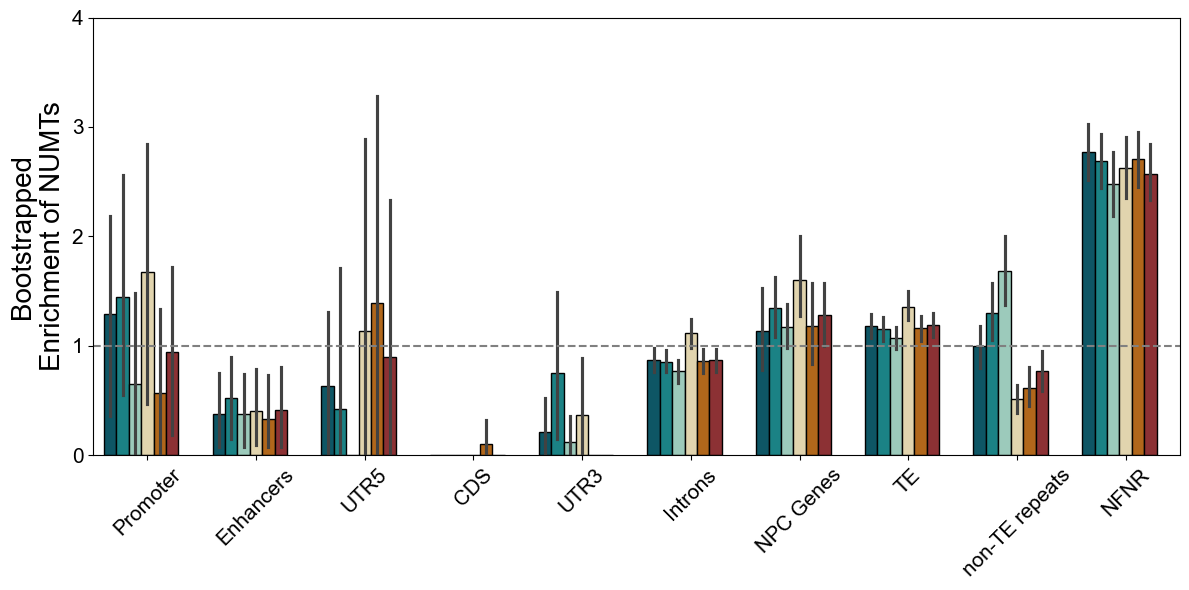

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial'

# Subset and reorder annotations.
merged_results = merged_results[merged_results['Feature'].isin(subset_annots)]
annot_order = [dict_annot[annot] for annot in subset_annots]

# Plot the enrichment values
plt.figure(figsize=(12, 6))

sns.barplot(
    x='Feature_Annotation', 
    y='Enrichment', 
    hue='Species', 
    order=annot_order, 
    hue_order=species_order, 
    data=merged_results, 
    palette=palette7,
    errorbar=('pi',95),  # Show confidence intervals as standard deviation
    edgecolor='black'
)

# Customize the plot
plt.xlabel('')
plt.ylabel('Bootstrapped\nEnrichment of NUMTs', fontsize=20)
plt.xticks(rotation=45, fontsize=15)

# Ytick labels increments of 1.
plt.yticks(ticks=range(0, int(merged_results['Enrichment'].max()) + 1, 1), fontsize=15)

# plt.legend(title='', bbox_to_anchor=(0.5,1), fontsize=10*augm_factor, frameon=False)
plt.legend([], frameon=False)
plt.tight_layout()

plt.axhline(y=1, color='gray', linestyle='--', label='Baseline Enrichment')

# # Add labels A, B to the upper left of each subplot
# labels = ['B']
# for i, ax in enumerate(plt.gcf().axes):
#     ax.text(-0.1, 1, labels[i], transform=ax.transAxes, fontsize=25 * 1.5, fontweight='bold', va='center', ha='right')

# Export.
plt.savefig(f"plots/png/figure_multiplot_funct_annot_50bpflanks.png", bbox_inches='tight', dpi=600)
plt.savefig(f"plots/pdf/figure_multiplot_funct_annot_50bpflanks.pdf", bbox_inches='tight', dpi=600)

In [10]:
te_enrichment_per_species = merged_results[merged_results['Feature'] == 'te'].groupby('Species')['Enrichment'].median()
te_enrichment_per_species

Species
B. orangutan    1.161714
Bonobo          1.179609
Chimpanzee      1.159693
Gorilla         1.357612
Human           1.073611
S. orangutan    1.192865
Name: Enrichment, dtype: float64

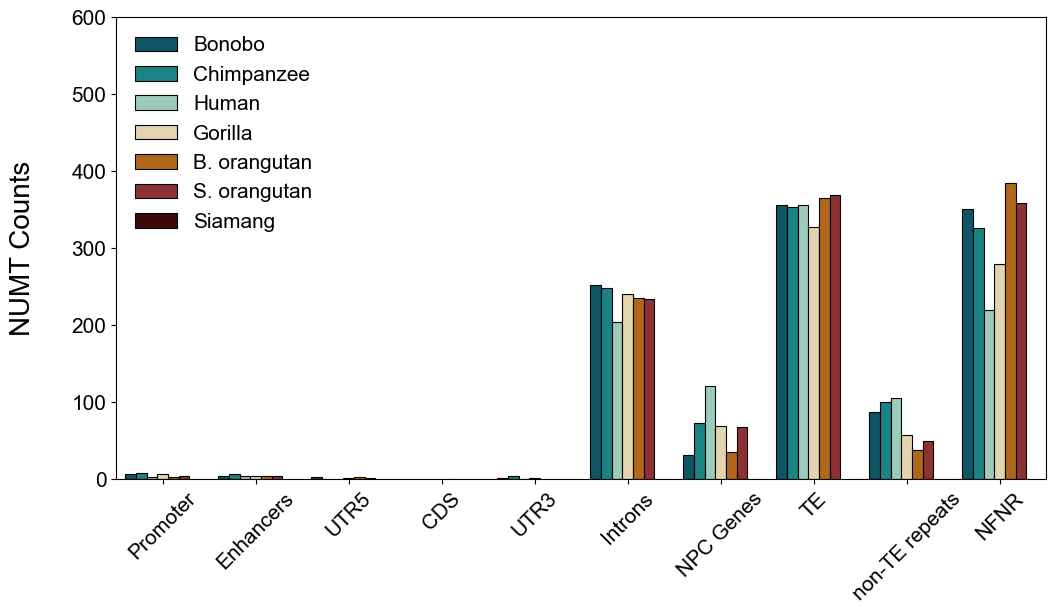

In [60]:
def plot_counts_numts(data_type='totalbp', ax=None):
    # NUMT counts.
    numts = pd.read_table('../diff_flank_sizes/merged_and_prepared_data.tsv')
    numts = numts.loc[:, numts.columns.str.endswith(data_type) | numts.columns.isin(['Assembly','Species',f'NUMT_{data_type}'])]
    numts = numts.loc[:, numts.columns.str.startswith('flanks') | numts.columns.isin(['Assembly','Species',f'NUMT_{data_type}'])]
    ass_order = ['mPanPan1', 'mPanTro3', 'CHM13', 'mGorGor1', 'mPonPyg2', 'mPonAbe1']
    numts = numts.set_index('Assembly').reindex(ass_order).reset_index()
    numts = numts.melt(id_vars=['Assembly','Species'])
    numts['Annotation_name'] = numts['variable'].str.split('_').str[2:-1].str.join('_')
    numts.loc[ numts['variable']==f'NUMT_{data_type}', 'Annotation_name' ] = "all NUMTs"

    numts['Species'] = numts['Assembly'].map(assembly_to_species)
    
    
    numts['Annotation_alt_name'] = [ dict_annot[annot] for annot in numts['Annotation_name'] ]

    # Set the figure size.
    plt.figure(figsize=(12, 6))

    # Change scale to kilobases (Kb).
    if data_type == 'totalbp':
        numts['value'] = numts['value'] / 1000

    # Change order of xlabels.
    # order = ['all NUMTs']+subset_annots
    order = subset_annots
    order = [ dict_annot[annot] for annot in order ]

    # Plot.
    sns.barplot( ax=ax, data=numts, x='Annotation_alt_name', y='value', hue='Species', palette=palette7, hue_order=species_order, order=order, edgecolor='black', linewidth=0.8 )

    plt.xticks(rotation=45, size=15)
    # plt.yscale('log')
    plt.xlabel("")
    plt.yticks(size=15)
    plt.ylabel(f'NUMT {data_type}\n', size=20)
    if data_type == 'totalbp':
        plt.ylabel(f'NUMT Total Length (Kb)\n', size=25)
    elif data_type == 'counts':
        plt.ylabel(f'NUMT Counts\n', size=20)
    plt.legend(frameon=False, fontsize=15)

    plt.ylim([0,600])

    # # Add labels A, B to the upper left of each subplot
    # labels = ['A']
    # for i, ax in enumerate(plt.gcf().axes):
    #     ax.text(-0.1, 1, labels[i], transform=ax.transAxes, fontsize=25 * 1.5, fontweight='bold', va='center', ha='right')

    # return numts


plot_counts_numts(data_type='counts')


/var/folders/2x/ttb5cz0x6fz9hqwqj4cxr2240000gn/T/ipykernel_47753/4283877434.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False, fontsize=15)
/var/folders/2x/ttb5cz0x6fz9hqwqj4cxr2240000gn/T/ipykernel_47753/2322490396.py:12: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[0].set_ylim(0, 600)


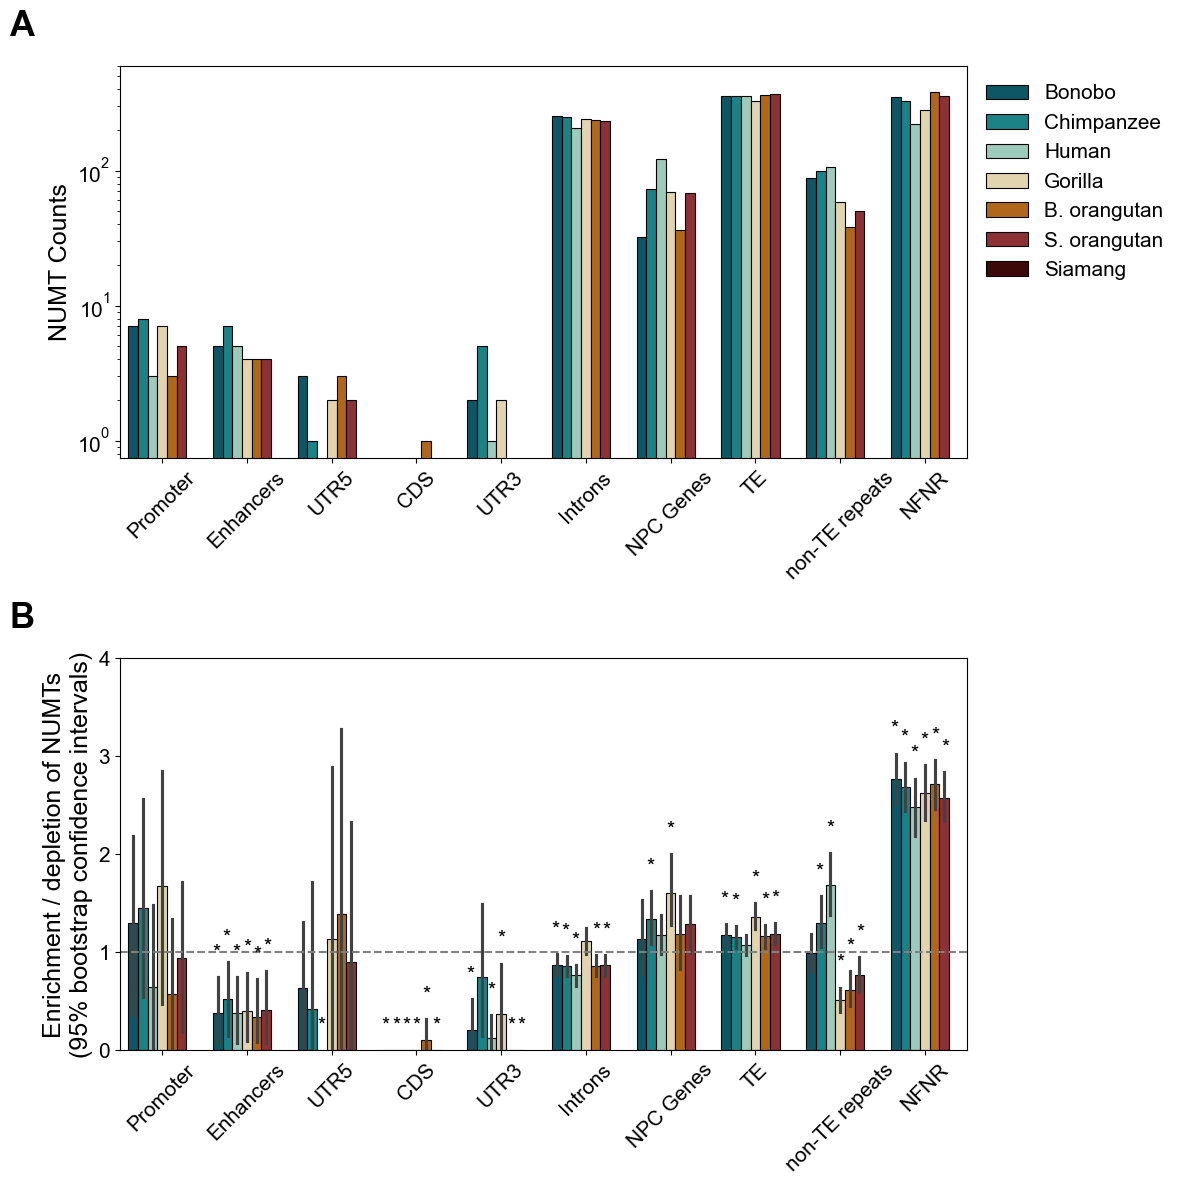

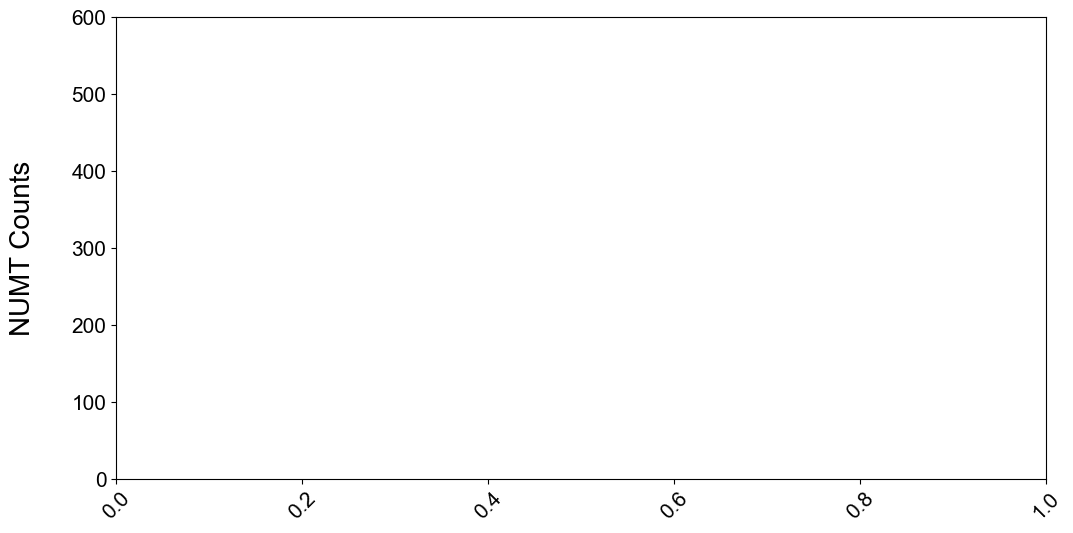

In [69]:
fig, axes = plt.subplots(2, 1, figsize=(12, 12))  # Create a figure with 2 subplots side by side
fig.subplots_adjust(hspace=0.1)  # Adjust the space between subplots

# Plot 'a' on the first subplot
plot_counts_numts(data_type='counts', ax=axes[0])
# axes[0].set_title('NUMT Counts', fontsize=20)
axes[0].set_xlabel('')
axes[0].set_yscale('log')
axes[0].set_ylabel('NUMT Counts', fontsize=18)
axes[0].tick_params(axis='x', rotation=45, labelsize=15)
axes[0].tick_params(axis='y', labelsize=15)
axes[0].set_ylim(0, 600)
axes[0].legend(frameon=False, loc='upper left', fontsize=15)

# Plot 'b' on the second subplot
sns.barplot(
    ax=axes[1],
    data=merged_results,
    x='Feature_Annotation',
    y='Enrichment',
    hue='Species',
    palette=palette7,
    hue_order=species_order,
    order=annot_order,
    edgecolor='black',
    errorbar=('pi',95),
    linewidth=0.8
)
# axes[1].set_title('Bootstrapped Enrichment of NUMTs', fontsize=20)
axes[1].set_xlabel('')
axes[1].set_ylabel('Enrichment / depletion of NUMTs\n(95% bootstrap confidence intervals)', fontsize=18)
axes[1].tick_params(axis='x', rotation=45, labelsize=15)
axes[1].tick_params(axis='y', labelsize=15)
axes[1].legend([], frameon=False)
axes[1].set_ylim(0, 4)
axes[1].set_yticks(range(0, 5, 1))

# Add a horizontal line at y=1 in the second plot
axes[1].axhline(y=1, color='gray', linestyle='--', label='Baseline Enrichment')

axes[0].legend(frameon=False, bbox_to_anchor=(1, 1), loc='upper left', fontsize=15)

# Add labels A, B to the upper left of each subplot
labels = ['A', 'B']
for i, ax in enumerate(axes):
    ax.text(-0.1, 1.1, labels[i], transform=ax.transAxes, fontsize=25, fontweight='bold', va='center', ha='right')


# Add significance stars if confidence intervals do not overlap 1
for i, feature in enumerate(annot_order):
    for j, species in enumerate(species_order):
        subset = merged_results[
            (merged_results['Feature_Annotation'] == feature) &
            (merged_results['Species'] == species)
        ]
        if not subset.empty:
            ci_low, ci_high = subset['Enrichment'].quantile([0.025, 0.975])
            if ci_low > 1 or ci_high < 1:  # Check if CI does not overlap 1
                axes[1].text(
                    i + j * 0.12 - 0.36,  # Adjust x-coordinate for grouped barplots
                    ci_high + 0.15,  # Place the star slightly closer above the upper confidence interval
                    '*',  # Star symbol
                    ha='center', va='bottom', fontsize=15, color='black'
                )



# Adjust layout
fig.tight_layout()

# Save the combined plot
fig.savefig("plots/png/combined_subplot.png", bbox_inches='tight', dpi=600)
fig.savefig("plots/pdf/combined_subplot.pdf", bbox_inches='tight', dpi=600)

